Proszę napisać program, który będzie odgadywać język w jakim napisany jest tekst.

Przydatny będzie program z zadania 3 (ngramy) oraz miary odległości (metryki):

- kosinusowa (cosinusowa),
- euklidesowa,
- taksówkowa (Manhattan),
- maksimum.

Przykładowe wyjście:

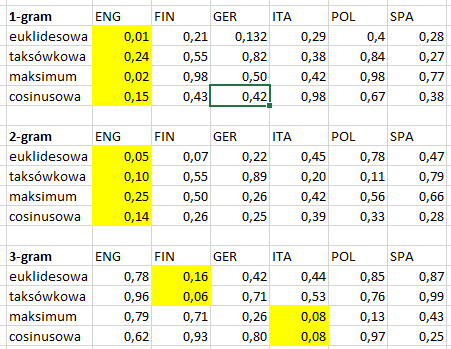

In [6]:
import re
import os
from collections import Counter
import math

def wczytaj_katalog(katalog):
    caly_tekst = ""

    # iteracja po wszystkich plikach w katalogu
    for nazwa_pliku in os.listdir(katalog):
        sciezka = os.path.join(katalog, nazwa_pliku)

        if os.path.isfile(sciezka) and nazwa_pliku.endswith(".txt"):
            with open(sciezka, "r", encoding="utf-8") as f:
                tekst = f.read().lower()
                # zostawiamy tylko litery i spacje
                tekst = re.sub(r"[^a-ząćęłńóśżźàüå ]", "", tekst)
                caly_tekst += tekst + " "  # dodajemy spację między plikami
    return caly_tekst
    
def wczytaj_tekst(plik):
    with open(plik, "r") as plik:
        tekst = plik.read().lower()
        return re.sub(r"[^a-ząćęłńóśżź ]", "", tekst)
        
def ngramy(tekst, n):
    return [tekst[i:i+n] for i in range(len(tekst)-n+1)]

def policz_ngramy(tekst, n):
    return dict(Counter(ngramy(tekst, n)))

def ranking(ngram_dict):
    return sorted(ngram_dict.items(), key=lambda x: x[1], reverse=True)

def normalize(counter):
    total = sum(counter.values())
    return {k: v/total for k,v in counter.items()}

def vector_union_keys(a, b):
    return set(a.keys()) | set(b.keys())

def euclidean(a, b):
    keys = vector_union_keys(a,b)
    return math.sqrt(sum((a.get(k,0) - b.get(k,0))**2 for k in keys))

def manhattan(a, b):
    keys = vector_union_keys(a,b)
    return sum(abs(a.get(k,0) - b.get(k,0)) for k in keys)

def chebyshev(a, b):
    keys = vector_union_keys(a,b)
    return max(abs(a.get(k,0) - b.get(k,0)) for k in keys)

def cosine(a, b):
    keys = vector_union_keys(a,b)
    dot = sum(a.get(k,0)*b.get(k,0) for k in keys)
    norm_a = math.sqrt(sum(a.get(k,0)**2 for k in keys))
    norm_b = math.sqrt(sum(b.get(k,0)**2 for k in keys))
    if norm_a==0 or norm_b==0:
        return 1
    return 1 - dot/(norm_a*norm_b)

def stworz_profil(tekst, n=2):
    return normalize(policz_ngramy(tekst, n))

def detect_language(tekst, profiles, n=2):
    tekst_profile = stworz_profil(tekst, n)
    wyniki = {}

    for lang, profile in profiles.items():
        wyniki[lang] = {
            "euclidean": euclidean(tekst_profile, profile),
            "manhattan": manhattan(tekst_profile, profile),
            "chebyshev": chebyshev(tekst_profile, profile),
            "cosine": cosine(tekst_profile, profile)
        }
    return wyniki

korpusCZE = wczytaj_katalog("KORPUSY/CZE")
korpusENG = wczytaj_katalog("KORPUSY/ENG")
korpusEPO = wczytaj_katalog("KORPUSY/EPO")
korpusESP = wczytaj_katalog("KORPUSY/ESP")
korpusGER = wczytaj_katalog("KORPUSY/GER")
korpusITA = wczytaj_katalog("KORPUSY/ITA")
korpusPOL = wczytaj_katalog("KORPUSY/POL")
korpusSVK = wczytaj_katalog("KORPUSY/SVK")
korpusSWE = wczytaj_katalog("KORPUSY/SWE")

LANG_PROFILES = {
    "CZE": stworz_profil(korpusCZE),
    "ENG": stworz_profil(korpusENG),
    "EPO": stworz_profil(korpusEPO),
    "ESP": stworz_profil(korpusESP),
    "GER": stworz_profil(korpusGER),
    "ITA": stworz_profil(korpusITA),
    "POL": stworz_profil(korpusPOL),
    "SVK": stworz_profil(korpusSVK),
    "SWE": stworz_profil(korpusSWE)
}

text_to_check = "Nad rzeczką opodal krzaczka Mieszkała kaczka-dziwaczka, Lecz zamiast trzymać sie rzeczki Robiła piesze wycieczki Raz poszła więc do fryzjera: „Poproszę o kilo sera!” Tuż obok był apteka: „Poproszę mleka pięć deka”. Z apteki poszła do praczki kupować pocztowe znaczki. Gryzły się kaczki okropnie: „A niech tę kaczkę gęś kopnie!” Znosiła jaja na twardo I miała czubek z kokardą, A przy tym, na przekór kaczkom, Czesała się wykałaczką."
wyniki = detect_language(text_to_check, LANG_PROFILES, n=2)

# posortowanie wyników po metryce kosinusowej (najlepszy = najmniejsza wartość)
wyniki_sorted = sorted(wyniki.items(), key=lambda x: x[1]['cosine'])

print("prawdopodobieństwo należenia do języka:")
for lang, distances in wyniki_sorted:
    print(f"{lang}: {distances}")





    

prawdopodobieństwo należenia do języka:
POL: {'euclidean': 0.07988983597596999, 'manhattan': 1.0058499060365058, 'chebyshev': 0.029498095087898232, 'cosine': 0.3517597017823514}
SVK: {'euclidean': 0.09910879135045941, 'manhattan': 1.257986174105523, 'chebyshev': 0.03480278422273782, 'cosine': 0.531246806594067}
CZE: {'euclidean': 0.10275641384026683, 'manhattan': 1.302074600975516, 'chebyshev': 0.034801137371805, 'cosine': 0.5583992775693687}
EPO: {'euclidean': 0.11395621169947237, 'manhattan': 1.3870183633270183, 'chebyshev': 0.03480278422273782, 'cosine': 0.605349193955638}
ITA: {'euclidean': 0.11558940967775866, 'manhattan': 1.4318554060909678, 'chebyshev': 0.03480039706374348, 'cosine': 0.6437099763546303}
ESP: {'euclidean': 0.11835756077592761, 'manhattan': 1.4397669034652487, 'chebyshev': 0.034795983776628556, 'cosine': 0.6521330717956653}
SWE: {'euclidean': 0.12270469971388738, 'manhattan': 1.5609868158183875, 'chebyshev': 0.03480278422273782, 'cosine': 0.7595235952863123}
ENG: 